In [108]:
# === SETUP: Run this first! ===
import os
import sys

# Change to project root and add to Python path
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)  # Goes up one level from 'notebooks/'
os.chdir(project_root)
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"tsnn module path: {os.path.join(project_root, 'tsnn')}")

Project root: /
tsnn module path: /tsnn


In [147]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
import torch
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader
import importlib
import sys
sys.path.append('/Users/cyrilgarcia/notebooks/tsnn/')

import tsnn

from tsnn.generators import generators
from tsnn import tstorch
from tsnn.benchmarks import benchmark_comparison, ml_benchmarks, torch_benchmarks
from tsnn import utils
from tsnn.tstorch import transformers
import torch.nn.functional as F
import math
from typing import Optional

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from torch import nn
from tqdm import tqdm
device = 'mps'

plt.style.use('ggplot')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [148]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

In [149]:
# In this notebook we will implement a basic ablation stusdy on attention heads to understand how models learn to predict different effects.

In [299]:
def keep_topk_per_row3(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out

In [300]:
def keep_by_max_value2(x, frac=0.2):
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    out = (x >= threshold).to(x.dtype)
    return out


# First test by hand

## Running the model

In [223]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def causal_mask_radius(b, h, q_idx, kv_idx):
    return (q_idx >= kv_idx) & (q_idx <= kv_idx+1)

def plot_mask(mask_fn, seq_len=20, title=None, device="cpu"):
    """
    Plot a binary attention mask defined by mask_fn(b,h,q_idx,kv_idx)
    as a (seq_len x seq_len) matrix.
    """
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device) 
    h = torch.zeros(1, device=device)

    mask = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])
    mask = mask.float().cpu()

    return pd.DataFrame(mask).style.background_gradient(axis=None).format(precision=0)

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool


In [224]:
def get_ols_corr(N_fea, T_train, rho, oos=True):
    ratio = N_fea/T_train
    if oos:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio/(1-ratio))
    else:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio)

In [225]:
# Main parameters

T=4000
n_rolling = 10
n_f = 20
n_ts = 10

rho = 0.4
effect = 'd_all'


In [226]:
# Build data

if n_f < 10:
    pct_zero_corr = 0
else:
    pct_zero_corr = 0.5

c = rho/np.sqrt((1-pct_zero_corr)*n_f)

arg_list = {'d_lin': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
            'd_cond': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
            'd_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
            'd_cs': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
            'd_cs_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
            'd_all': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
            }

z = generators.Generator(T, n_ts, n_f)

z.generate_dataset(
        pct_zero_corr=arg_list[effect]['pct_zero_corr'],
        split_conditional=arg_list[effect]['split_conditional'],
        split_shift=arg_list[effect]['split_shift'],
        split_seasonal=arg_list[effect]['split_seasonal'],
        split_cs=arg_list[effect]['split_cs'],
        split_cs_shift=arg_list[effect]['split_cs_shift'],
        random_ts_shift=n_rolling-1,
        low_corr=c,
        high_corr=c,
        shuffle_cs=True
    )

z.get_dataloader()


In [ ]:
# Define a list of models

embeddings_dict = {'d_lin': "none", 'd_cond': "none", 'd_shift': "T", 'd_cs': "C", 'd_cs_shift': "both", 'd_all': "both"}

mask = causal_mask
mask_c = build_attention_mask(mask, n_rolling, device=device)


models_torch = {
    'full_attention_TC': models.CustomBiDimensionalTransformer(
        n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=1,
        dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings=embeddings_dict[effect],
    ).to(device),
    # 'max2_sparse_attention_CC': models.CustomBiDimensionalTransformer(
    #     n_ts, n_f, n_rolling, mask=mask_c, layers='CC', nhead=16,
    #     dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_by_max_value2, roll_y=True, embeddings=embeddings_dict[effect],
    # ).to(device),
   
}


Running correl level: 0.4
Running model: full_attention_TC


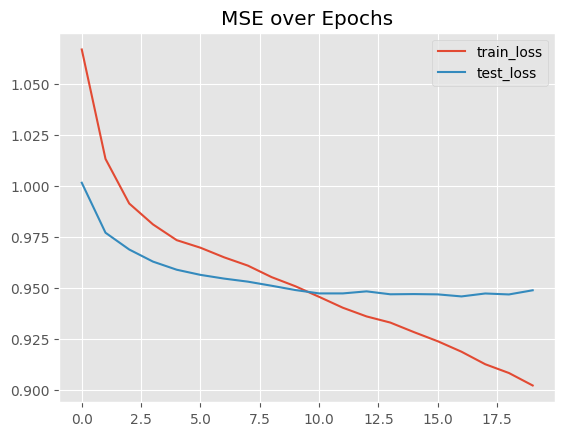

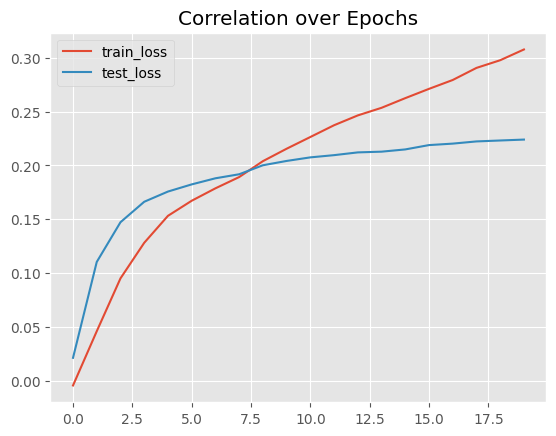

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [228]:
# Code to run the model with the parameters above.

res_train = []
res_test = []

print("Running correl level:", rho)
theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


models_torch = {
    k: torch_benchmarks.TorchWrapper(
        models_torch[k], 
        optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
        loss_fn=nn.MSELoss()  
    ) for k in models_torch
}


z.get_dataloader(n_rolling=n_rolling, roll_y=True)
for k in models_torch:
    print("Running model:", k)
    models_torch[k].fit(z.train, test=z.test, epochs=20, plot=True, verbose=0)
    

comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
model_names=[k for k in models_torch]
)

corr_train = comp.correl(z, mode="train", return_values=True)
corr_test  = comp.correl(z, mode="test",  return_values=True)

# for k in models_torch:

#     train_corr = corr_train.loc[k, "optimal"]
#     test_corr  = corr_test.loc[k, "optimal"]

#     res_train.append({
#         "rho": rho,
#         "model": k,
#         "train_corr_optimal": train_corr
#     })
#     res_test.append({
#         "rho": rho,
#         "model": k,
#         "test_corr_optimal": test_corr
#     })


# res_train.append({
#         "rho": rho,
#         "model": "theo_correl",
#         "train_corr_optimal": theo_correl_is
#     })
# res_test.append({
#         "rho": rho,
#         "model": "theo_correl",
#         "test_corr_optimal": theo_correl_oos
#     })


# res_train = pd.DataFrame(res_train)
# res_test  = pd.DataFrame(res_test)

# res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
# res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

In [229]:
# Here we want to see the full matrix of correlation to the optimal targets.

In [230]:
display(comp.correl(z, mode='train'))
display(comp.correl(z, mode='test'))

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


,true,optimal,linear,conditional,shift,cs,cs_shift
optimal,0.378,nan,nan,nan,nan,nan,nan
linear,0.172,0.468,nan,nan,nan,nan,nan
conditional,0.184,0.471,0.024,nan,nan,nan,nan
shift,0.172,0.474,0.026,0.023,nan,nan,nan
cs,0.174,0.475,0.028,0.029,0.036,nan,nan
cs_shift,0.192,0.473,0.025,0.035,0.033,0.029,nan
full_attention_TC,0.340,0.619,0.583,0.247,0.248,0.303,0.078


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


,true,optimal,linear,conditional,shift,cs,cs_shift
optimal,0.384,nan,nan,nan,nan,nan,nan
linear,0.181,0.469,nan,nan,nan,nan,nan
conditional,0.182,0.477,0.034,nan,nan,nan,nan
shift,0.171,0.473,0.020,0.034,nan,nan,nan
cs,0.189,0.479,0.035,0.040,0.027,nan,nan
cs_shift,0.189,0.475,0.025,0.027,0.039,0.034,nan
full_attention_TC,0.224,0.595,0.586,0.238,0.235,0.289,0.065


In [231]:
# Important info: having many heads is crucial to learning different effects!!!! It says with n_head = 2 we only capture the linear effect !!
# Actually is it the d_model the most important parameter??

# Actually in the "TC" model one really needs more head to learn more effects it seems 
# Seems a bit less true in "TCTC" ??

# Still seems a bit random..

## Running the model on the new data

In [311]:
# Parameters

T=4000
n_rolling = 10
n_f =4
n_ts = 10

rho = 0.5

# The possible effects are: lin, TS_shift, CS_shift, TSCS_shift, fea_cond, TS_cond, CS_cond

#list_effects1 = ["lin", "TS_shift", "CS_shift", "TSCS_shift", "fea_cond", "TS_cond", "CS_cond"]*2
list_effects1 = ["CS_shift"]*2 + ["CS_cond"]*2
#list_effects1 = ["TS_cond"]*2


print(list_effects1)

['CS_shift', 'CS_shift', 'CS_cond', 'CS_cond']


In [312]:
# Define the data:

z = generators.Generator(T, n_ts, n_f)

z.generate_dataset_gr_simple(
        global_corr=rho, 
        correl_split_by_fea=None, 
        list_type_effects=list_effects1,
        list_type_interaction=["cond"], 
        random_ts_shift=n_rolling,
    )

z.get_dataloader()


In [313]:
# Define the models

mask = causal_mask
mask_c = build_attention_mask(mask, n_rolling, device=device)


models_torch = {
    # 'full_attention_TC': models.CustomBiDimensionalTransformer(
    #     n_ts, n_f, n_rolling, mask=mask_c, layers='CC', nhead=16,
    #     dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings="C",
    # ).to(device),
    'top3_sparse_attention_CC': models.CustomBiDimensionalTransformer(
        n_ts, n_f, n_rolling, mask=mask_c, layers='CC', nhead=2,
        dropout=0.1, d_model=64, dim_feedforward=256, sparsify=keep_topk_per_row3, roll_y=True, embeddings="C",
    ).to(device),

}

Running correl level: 0.5
Running model: top3_sparse_attention_CC


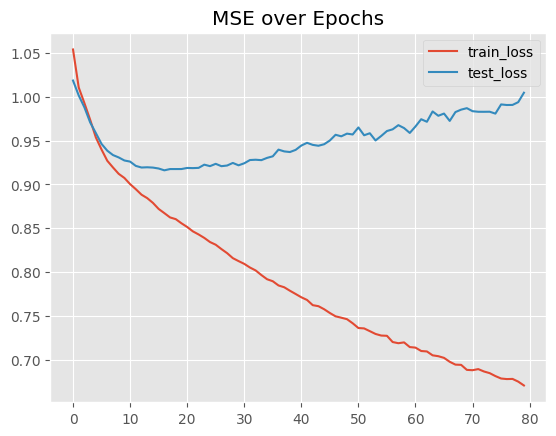

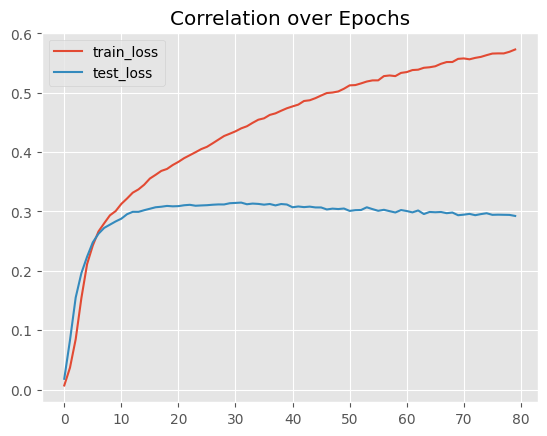

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [314]:
# Code to run the model with the parameters above.

res_train = []
res_test = []

print("Running correl level:", rho)
theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


models_torch = {
    k: torch_benchmarks.TorchWrapper(
        models_torch[k], 
        optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
        loss_fn=nn.MSELoss()  
    ) for k in models_torch
}


z.get_dataloader(n_rolling=n_rolling, roll_y=True)
for k in models_torch:
    print("Running model:", k)
    models_torch[k].fit(z.train, test=z.test, epochs=80, plot=True, verbose=0)
    

comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
model_names=[k for k in models_torch]
)

corr_train = comp.correl(z, mode="train", return_values=True)
corr_test  = comp.correl(z, mode="test",  return_values=True)

# for k in models_torch:
#     train_corr = corr_train.loc[k, "optimal"]
#     test_corr  = corr_test.loc[k, "optimal"]

#     res_train.append({
#         "rho": rho,
#         "model": k,
#         "train_corr_optimal": train_corr
#     })
#     res_test.append({
#         "rho": rho,
#         "model": k,
#         "test_corr_optimal": test_corr
#     })


# res_train.append({
#         "rho": rho,
#         "model": "theo_correl",
#         "train_corr_optimal": theo_correl_is
#     })
# res_test.append({
#         "rho": rho,
#         "model": "theo_correl",
#         "test_corr_optimal": theo_correl_oos
#     })


# res_train = pd.DataFrame(res_train)
# res_test  = pd.DataFrame(res_test)

# res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
# res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

In [315]:
display(comp.correl(z, mode='train'))
display(comp.correl(z, mode='test'))

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


,true,optimal,cs,conditional_cs
optimal,0.499,nan,nan,nan
cs,0.350,0.706,nan,nan
conditional_cs,0.359,0.716,0.010,nan
top3_sparse_attention_CC,0.623,0.631,0.531,0.368


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


,true,optimal,cs,conditional_cs
optimal,0.490,nan,nan,nan
cs,0.347,0.707,nan,nan
conditional_cs,0.347,0.709,0.003,nan
top3_sparse_attention_CC,0.289,0.562,0.530,0.267


## Ablation study

In [322]:

# Fixed ablate function to work with actual model
def ablate_attention_head(model, head_index=0, block_name='temporal', block_index=0):
    """
    Ablate a specific attention head of a specified block.
    
    Args:
        model: The actual PyTorch model (not the TorchWrapper)
        head_index: Index of the head to ablate (0-indexed, must be < nheads)
        block_name: 'temporal' or 'series'
        block_index: Which block (0 for first 'T', 1 for first 'C', etc.)
    
    Returns:
        hook: The registered hook (call hook.remove() to restore normal behavior)
    """
    block_count = 0
    target_block = None
    for block in model.blocks:
        if block_name in block:
            if block_count == block_index:
                target_block = block
                break
            block_count += 1
    
    if target_block is None:
        raise ValueError(f"Could not find {block_name} block at index {block_index}")
    
    self_attn = target_block[block_name].layers[0].self_attn
    
    # Validate head_index
    if head_index >= self_attn.nheads or head_index < 0:
        raise ValueError(f"head_index must be between 0 and {self_attn.nheads - 1}, got {head_index}")
    
    def ablation_hook(module, input):
        x = input[0]
        head_dim = x.shape[-1] // self_attn.nheads
        
        # Calculate start and end positions for the specific head
        start = head_index * head_dim
        end = start + head_dim
        
        # Zero out the specific head
        x[:, :, start:end] = 0
        return None
    
    hook = self_attn.out_proj.register_forward_pre_hook(ablation_hook)
    return hook

# Usage:
model1 = models_torch['full_attention_TC']

# Baseline (no ablation)
comp = benchmark_comparison.Comparator(models=[model1], model_names=['full_attention_TC'])

corr_train_baseline = comp.correl(z, mode="train", return_values=True)
corr_test_baseline = comp.correl(z, mode="test", return_values=True)

print(f"Baseline  - Train: {corr_train_baseline.loc['full_attention_TC', 'optimal']:.4f}, Test: {corr_test_baseline.loc['full_attention_TC', 'optimal']:.4f}")
#display(comp.correl(z, mode='train'))
display(comp.correl(z, mode='test'))

# Apply ablation to the ACTUAL MODEL inside TorchWrapper
hook = ablate_attention_head(model1.model, head_index=0, block_name='series', block_index=1)

# With ablation
corr_train_ablated = comp.correl(z, mode="train", return_values=True)
corr_test_ablated = comp.correl(z, mode="test", return_values=True)

print(f"Ablated   - Train: {corr_train_ablated.loc['full_attention_TC', 'optimal']:.4f}, Test: {corr_test_ablated.loc['full_attention_TC', 'optimal']:.4f}")
#display(comp.correl(z, mode='train'))
display(comp.correl(z, mode='test'))

hook.remove()



/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Baseline  - Train: 0.6349, Test: 0.5619


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


,true,optimal,cs,conditional_cs
optimal,0.490,nan,nan,nan
cs,0.347,0.707,nan,nan
conditional_cs,0.347,0.709,0.003,nan
full_attention_TC,0.287,0.563,0.532,0.265


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Ablated   - Train: 0.5148, Test: 0.4521


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


,true,optimal,cs,conditional_cs
optimal,0.490,nan,nan,nan
cs,0.347,0.707,nan,nan
conditional_cs,0.347,0.709,0.003,nan
full_attention_TC,0.232,0.451,0.488,0.151


In [323]:
# In this example we seem to see there is some specialization between the two effects.

In [279]:

# Usage:
model1 = models_torch['full_attention_TC']

# Baseline (no ablation)
comp = benchmark_comparison.Comparator(models=[model1], model_names=['full_attention_TC'])

corr_train_baseline = comp.correl(z, mode="train", return_values=True)
corr_test_baseline = comp.correl(z, mode="test", return_values=True)

print(f"Baseline  - Train: {corr_train_baseline.loc['full_attention_TC', 'optimal']:.4f}, Test: {corr_test_baseline.loc['full_attention_TC', 'optimal']:.4f}")
#display(comp.correl(z, mode='train'))
display(comp.correl(z, mode='test'))

# Apply ablation to the ACTUAL MODEL inside TorchWrapper
hook1 = ablate_attention_head(model1.model, head_index=0, block_name='series', block_index=0)
hook2 = ablate_attention_head(model1.model, head_index=1, block_name='series', block_index=0)

# With ablation
corr_train_ablated = comp.correl(z, mode="train", return_values=True)
corr_test_ablated = comp.correl(z, mode="test", return_values=True)

print(f"Ablated   - Train: {corr_train_ablated.loc['full_attention_TC', 'optimal']:.4f}, Test: {corr_test_ablated.loc['full_attention_TC', 'optimal']:.4f}")
#display(comp.correl(z, mode='train'))
display(comp.correl(z, mode='test'))

hook1.remove()
hook2.remove()



/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Baseline  - Train: 0.7566, Test: 0.7240


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


,true,optimal,cs,conditional_cs
optimal,0.503,nan,nan,nan
cs,0.360,0.713,nan,nan
conditional_cs,0.356,0.709,0.010,nan
full_attention_TC,0.365,0.725,0.788,0.241


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Ablated   - Train: 0.0243, Test: 0.0136


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


,true,optimal,cs,conditional_cs
optimal,0.503,nan,nan,nan
cs,0.360,0.713,nan,nan
conditional_cs,0.356,0.709,0.010,nan
full_attention_TC,0.009,0.013,0.013,0.005


In [236]:
# Basically from this we conclude the attention heads are not used to learn linear / conditional effects, maybe this is expected ??